# Sales Data Analysis Project
## 1. Load and Explore Data

In [1]:
import pandas as pd
df=pd.read_csv(r'C:\Users\Joey\Downloads\archive.zip')
df.head()
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

## 2. Total Sales and Category Ranking using SQL

In [2]:
import sqlite3


conn = sqlite3.connect(':memory:')


df.to_sql('sales', conn, index=False)

query1 = "SELECT SUM(Sales) AS TotalSales FROM sales"
result1 = pd.read_sql_query(query1, conn)
print(result1)

query2 = """
SELECT Category, SUM(Sales) AS TotalSales
FROM sales
GROUP BY Category
ORDER BY TotalSales DESC
"""
result2 = pd.read_sql_query(query2, conn)
print(result2)

     TotalSales
0  2.261537e+06
          Category   TotalSales
0       Technology  827455.8730
1        Furniture  728658.5757
2  Office Supplies  705422.3340


## 3. Monthly Sales Trend using pandas

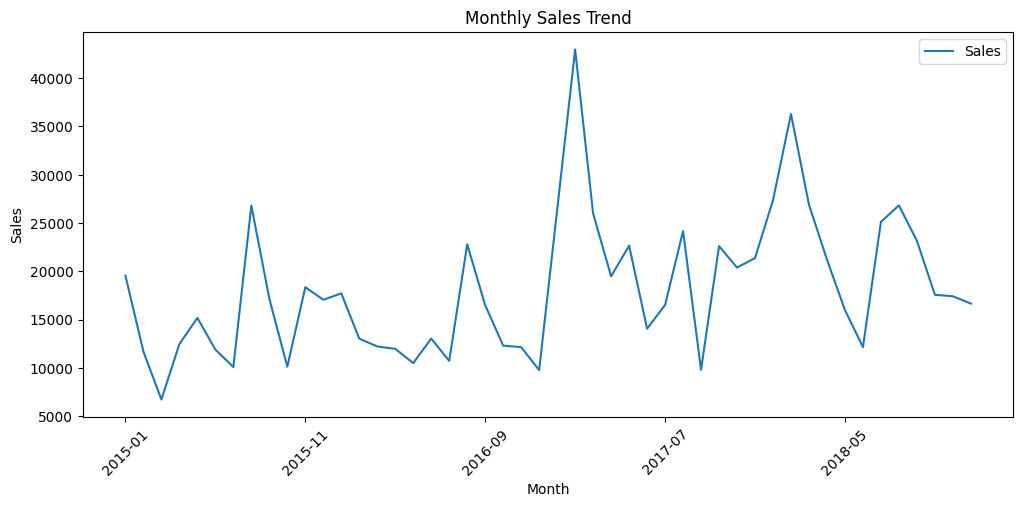

<Figure size 640x480 with 0 Axes>

In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Order Date'].astype(str)

import matplotlib.pyplot as plt
monthly_sales.plot(x='Month', y='Sales', kind='line', figsize=(12,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight');

In [4]:
print(monthly_sales.head(10))
print(monthly_sales.tail(10))

  Order Date      Sales    Month
0    2015-01  19546.163  2015-01
1    2015-02  11678.994  2015-02
2    2015-03   6716.044  2015-03
3    2015-04  12455.482  2015-04
4    2015-05  15165.051  2015-05
5    2015-06  11884.169  2015-06
6    2015-07  10075.740  2015-07
7    2015-08  26797.763  2015-08
8    2015-09  17158.932  2015-09
9    2015-10  10112.641  2015-10
   Order Date       Sales    Month
38    2018-03  26882.9530  2018-03
39    2018-04  21203.6070  2018-04
40    2018-05  15979.1570  2018-05
41    2018-06  12138.1558  2018-06
42    2018-07  25110.4795  2018-07
43    2018-08  26823.6900  2018-08
44    2018-09  23148.8700  2018-09
45    2018-10  17558.3220  2018-10
46    2018-11  17407.2700  2018-11
47    2018-12  16647.0420  2018-12


## 4. Key Findings
   
Total Sales: $2.26 million

Top Category: Technology ($827K)

Monthly Trend: Sales range from $10K to $27K, with peaks in August 2015 and September 2018.